## Notebook of 8 April 2026 (work in progress)

In [33]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [34]:
import networkx as nx
import itertools
from src.graphs.visualization import *
from src.hyperbolicity.gromov import compute_gromov_on_graph, evolve_topology_strategy
from src.graphs.utils import *
import random
import matplotlib.pyplot as plt

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


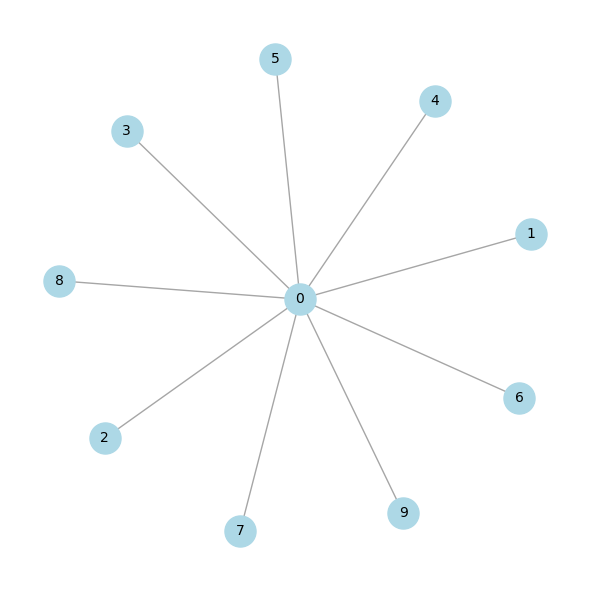

Initial Gromov Hyperbolicity: 0.0


In [ ]:
# --- CONFIGURATION ---
n_steps = 5
target = 'decrease'  # 'increase' o 'decrease'
strategy = 'mixed'     # 'add', 'remove', 'mixed'
p = 0.9 # useful if stategy is mixed
n = 10
type = 'cycle'  # 'cycle', 'complete', 'erdos_renyi', 'lattice'. 'star'

G = create_graph(type=type, n=n) 
pos = draw_layout(G)   
draw_graphs(G, pos)

actual_gromov, _, quadruples = compute_gromov_on_graph(G, return_history=True)
print(f"Initial Gromov Hyperbolicity: {actual_gromov}")


Step n. 0
We found 25 optimal edges.
Action: add edge (0, 4) (Value: 1.5000)


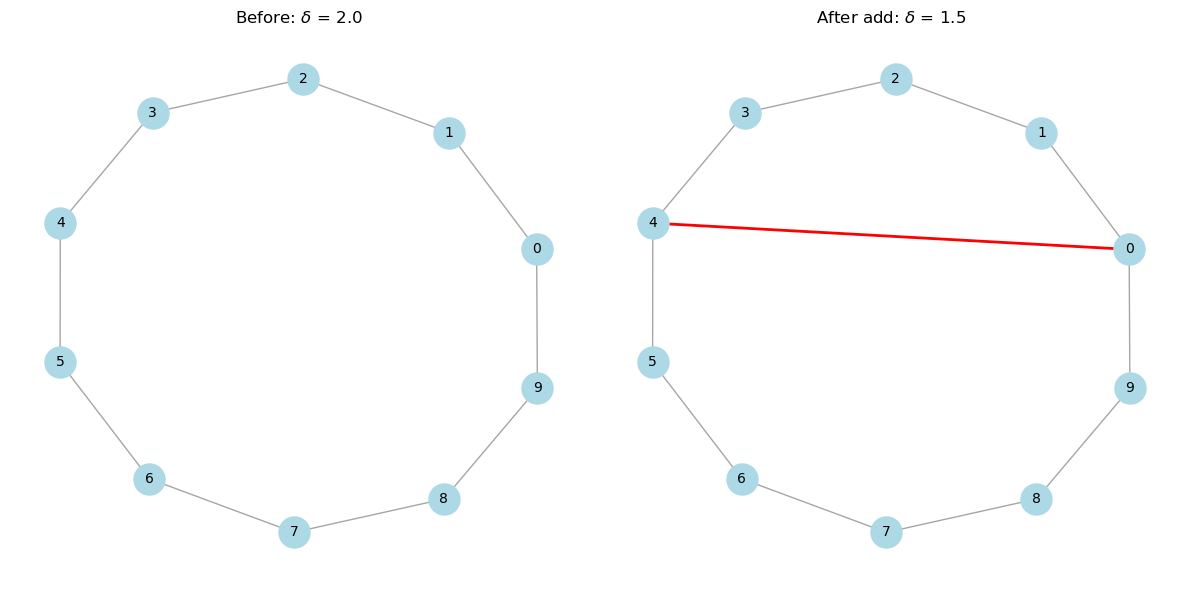

Quadruples: 1


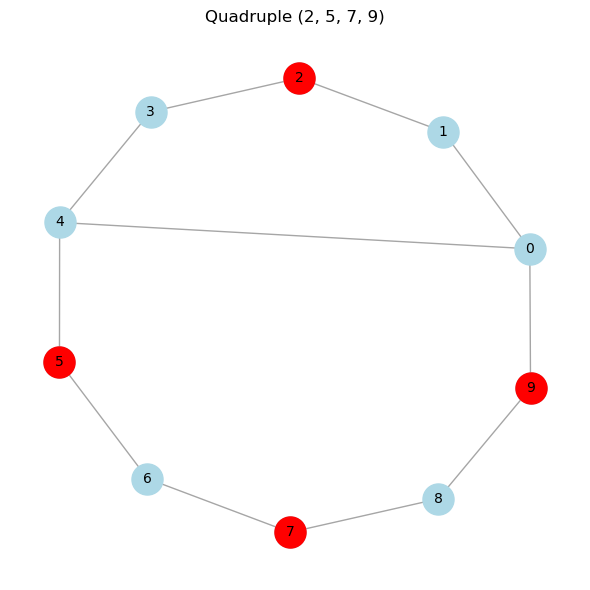


Step n. 1
We found 32 optimal edges.
Action: add edge (0, 2) (Value: 1.0000)


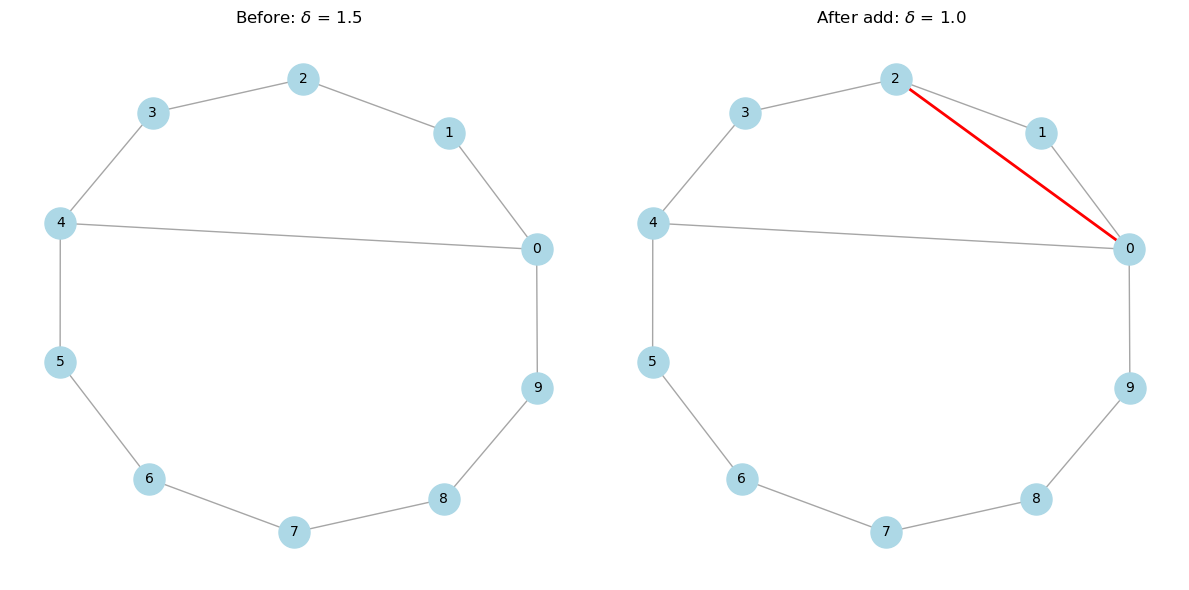

Quadruples: 31
Too many quadruples to visualize (31), showing only the first 3.


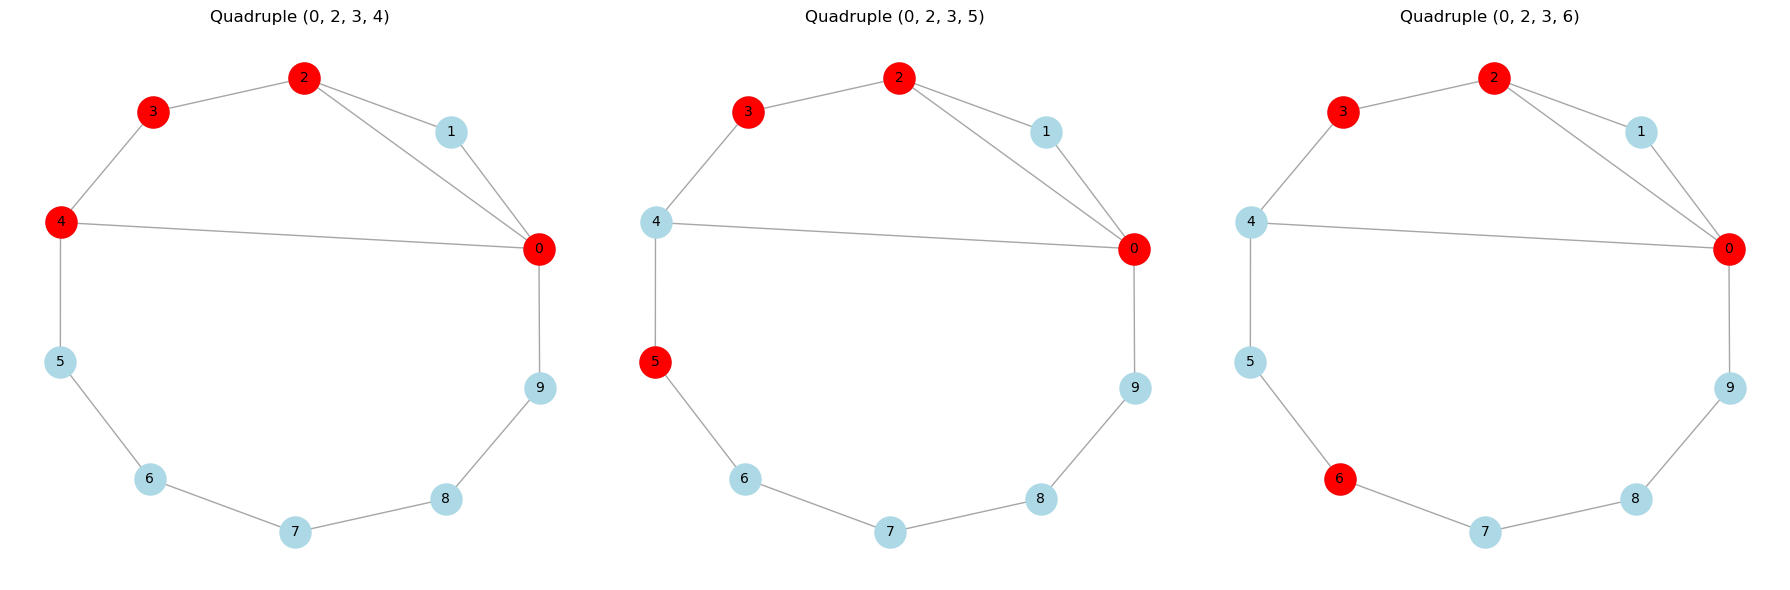


Step n. 2
Added random edge: (4, 7)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 20
Added random edge: (5, 7)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 13
Added random edge: (0, 6)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 25
Added random edge: (4, 8)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 34
Added random edge: (2, 4)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 18
Added random edge: (0, 7)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 15
Added random edge: (4, 6)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 8
We found 3 optimal edges.
Action: add edge (0, 8) (Value: 0.5000)


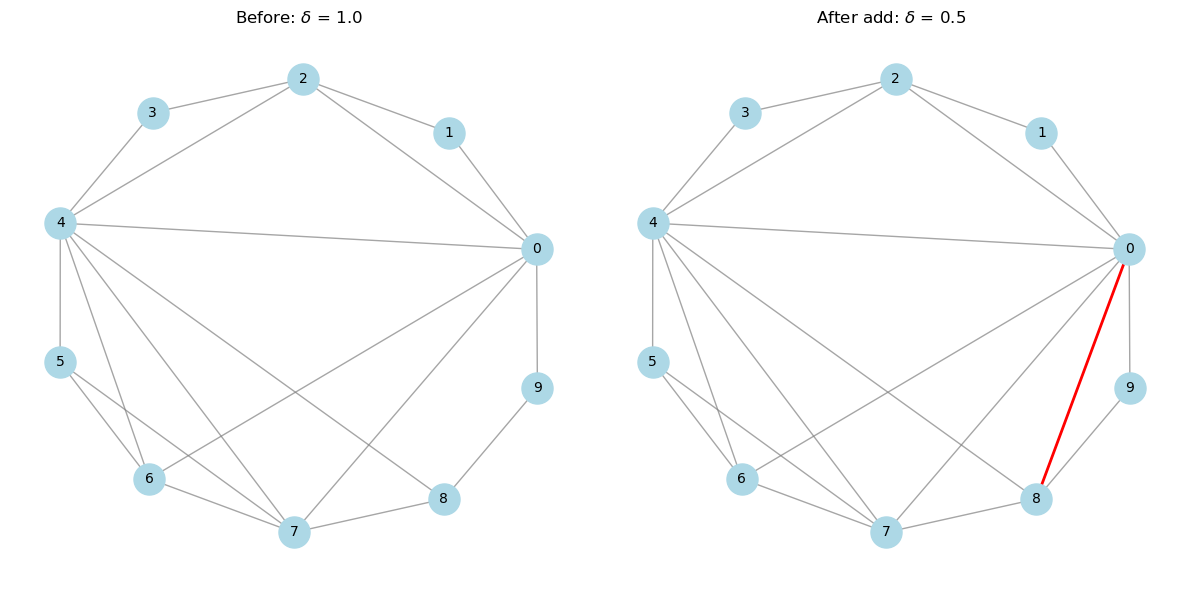

Quadruples: 89
Too many quadruples to visualize (89), showing only the first 3.


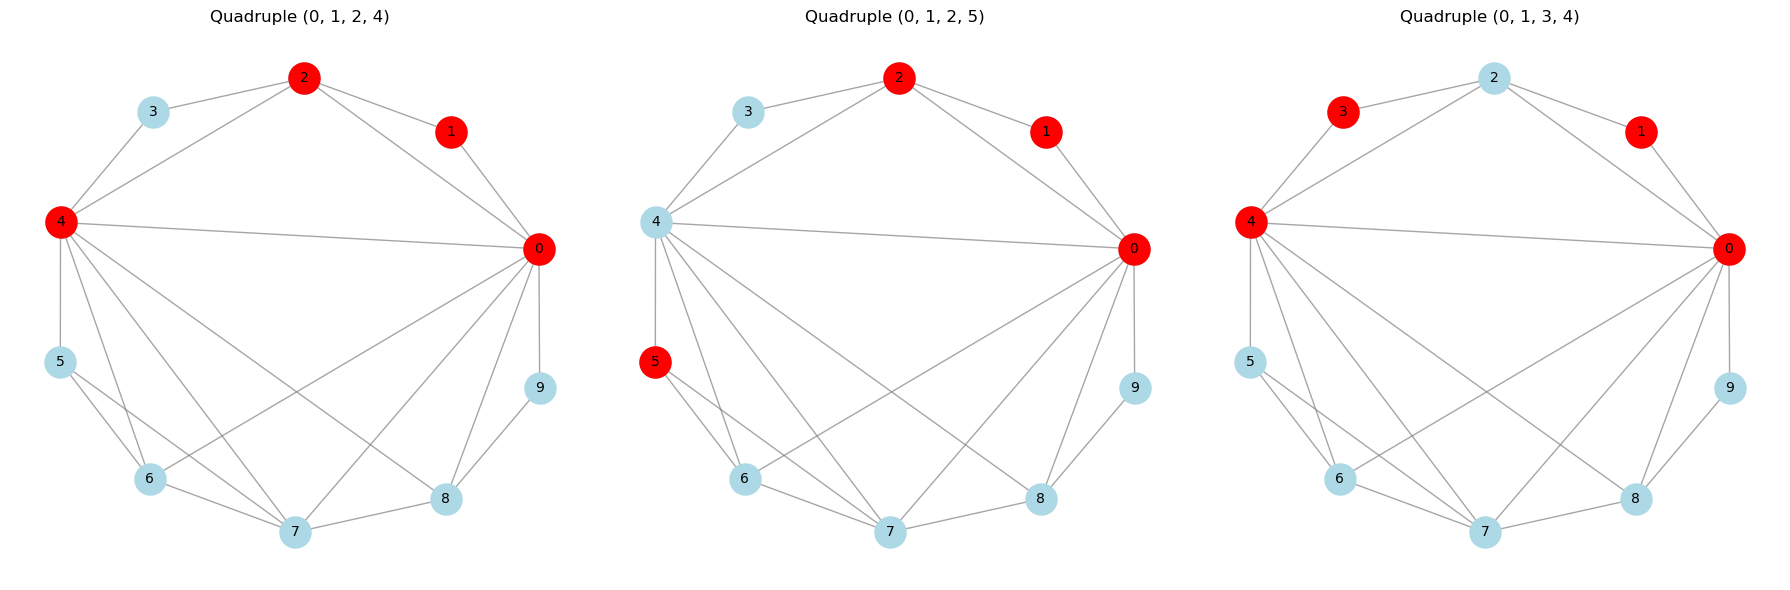


Step n. 3
Added random edge: (0, 3)
Current Gromov after fallback: 0.5
Number of quadruples after fallback: 77
Removed random edge: (0, 8)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 6
Added random edge: (5, 8)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 4
Added random edge: (1, 6)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 7
Added random edge: (1, 5)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 6
Added random edge: (2, 5)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 7
Added random edge: (2, 8)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 9
Added random edge: (1, 9)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 11
Added random edge: (1, 7)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 13
Added random edge: (2, 7)
Current Gromov after fallback: 1.0
Number of quadruples af

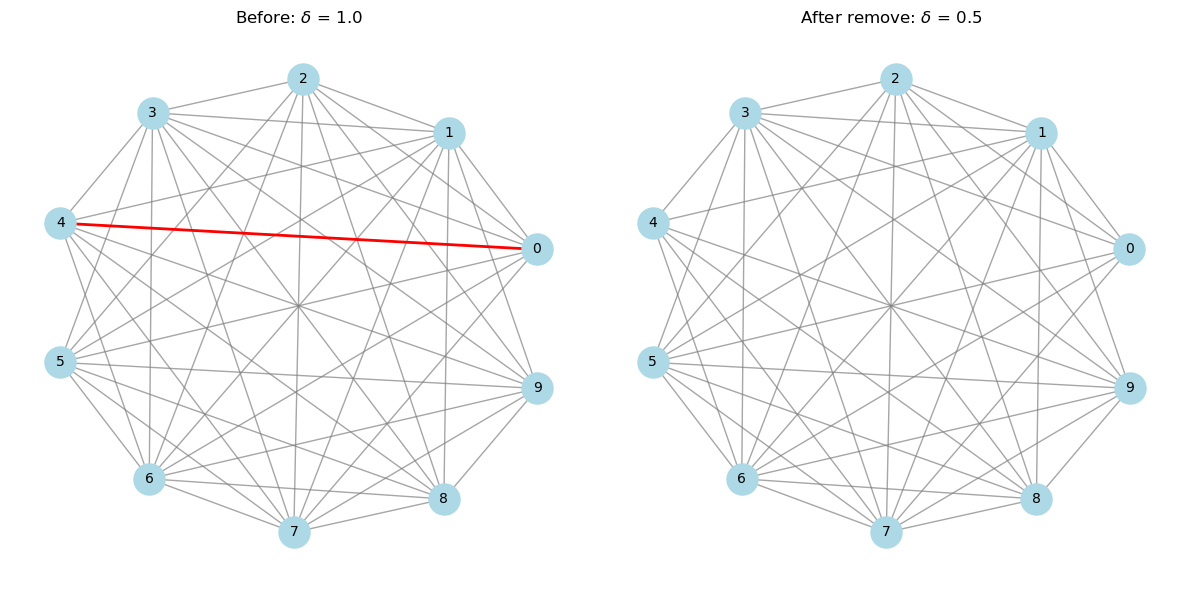

Quadruples: 70
Too many quadruples to visualize (70), showing only the first 3.


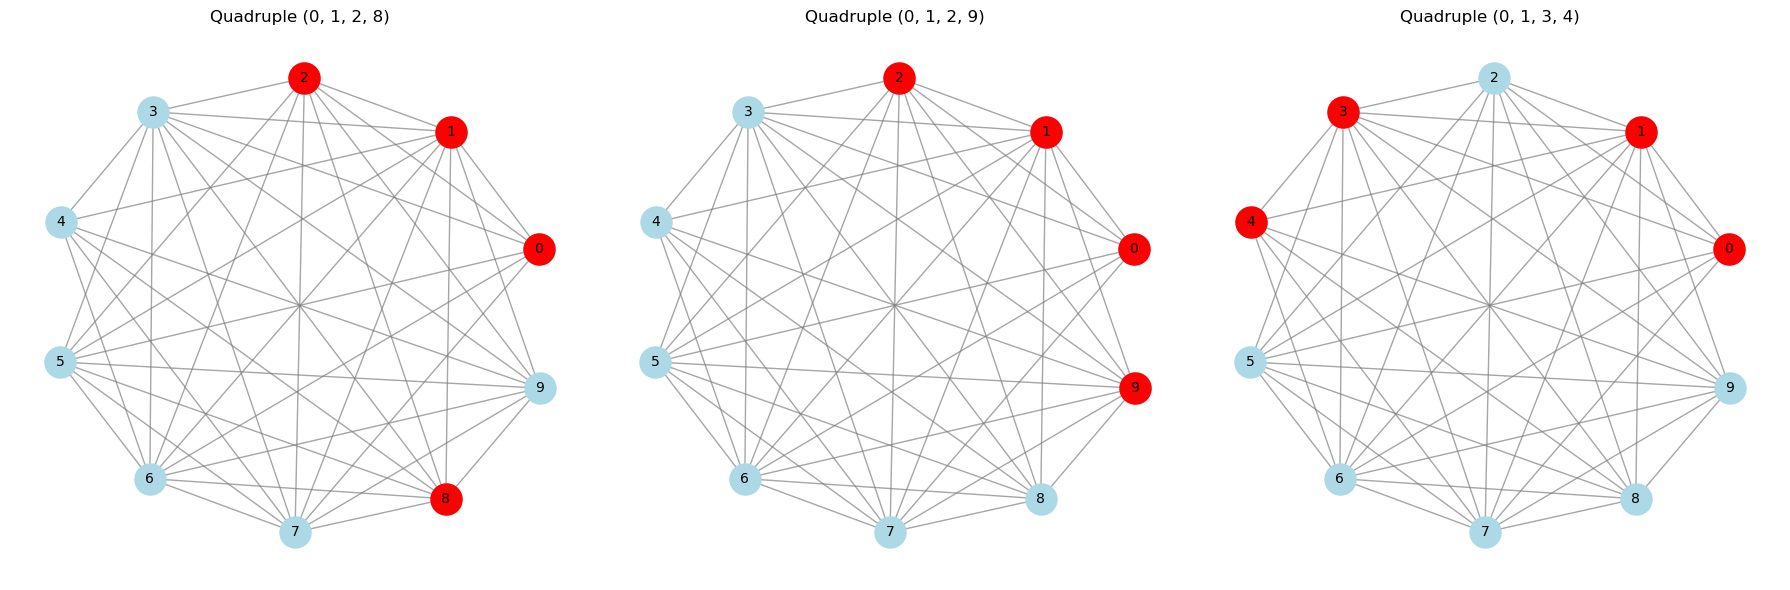

In [24]:
for step in range(n_steps):
    print(f"\n{'='*30}\nStep n. {step}\n{'='*30}")
    
    # 1. Trova le possibili modifiche
    found_edges = evolve_topology_strategy(G, pos=pos, target=target, strategy=strategy, p=p, max_steps=100)
    
    if not found_edges:
        actual_gromov = compute_gromov_on_graph(G)
        print('The final gromov is: ' + str(actual_gromov))
        print("No moves found. Stopping.")
        continue

    # 2. Ordina le modifiche (usando la tua logica sulla terza dimensione della tupla)
    # Assumendo found_edges sia [(azione, (u, v), valore), ...]
    #found_edges.sort(key=lambda x: x[2], reverse=(target == 'increase'))
    
    action, edge, delta_val = found_edges[0]
    print(f"Action: {action} edge {edge} (Value: {delta_val:.4f})")

    # 3. Applica la modifica
    G_old = G.copy()
    if action == 'add':
        G.add_edge(*edge)
    else:
        G.remove_edge(*edge)

    # 4. Calcolo nuovo stato
    new_gromov, _, new_quadruples = compute_gromov_on_graph(G, return_history=True)
    
    # 5. Visualizzazione compatta
    # Decidiamo cosa evidenziare in base all'azione
    h_edges = [[edge], None] if action == 'remove' else [None, [edge]]
    
    draw_graphs(
        [G_old, G], 
        [pos, pos], 
        titles=[
            f"Before: $\\delta$ = {actual_gromov}", 
            f"After {action}: $\\delta$ = {new_gromov}"
        ],
        highlight_edges=h_edges
    )
    print(f"Quadruples: {len(new_quadruples)}")
    draw_quadruples(G, pos, new_quadruples, max_to_draw=3)
    # 6. Aggiorna stato
    actual_gromov = new_gromov

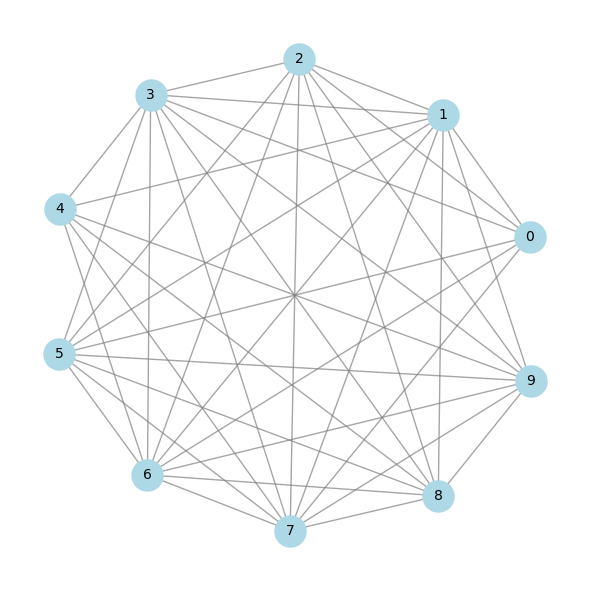

(<Figure size 600x600 with 1 Axes>, [<Axes: >])

In [25]:
compute_gromov_on_graph(G)
draw_graphs(G, pos)

## another test on star graph

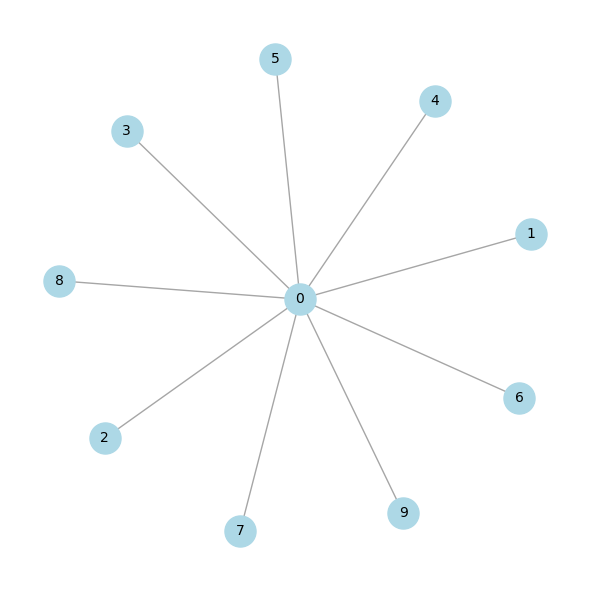

Initial Gromov Hyperbolicity: 0.0


In [31]:
# --- CONFIGURATION ---
n_steps = 5
target = 'increase'  # 'increase' o 'decrease'
strategy = 'mixed'     # 'add', 'remove', 'mixed'
p = 0.9 # useful if stategy is mixed
n = 10
type = 'star'  # 'cycle', 'complete', 'erdos_renyi', 'lattice'. 'star'

G = create_graph(type=type, n=n) 
pos = draw_layout(G)   
draw_graphs(G, pos)

actual_gromov, _, quadruples = compute_gromov_on_graph(G, return_history=True)
print(f"Initial Gromov Hyperbolicity: {actual_gromov}")


Step n. 0
Added random edge: (5, 8)
Current Gromov after fallback: 0.0
Number of quadruples after fallback: 210
We found 14 optimal edges.
Action: add edge (1, 5) (Value: 0.5000)


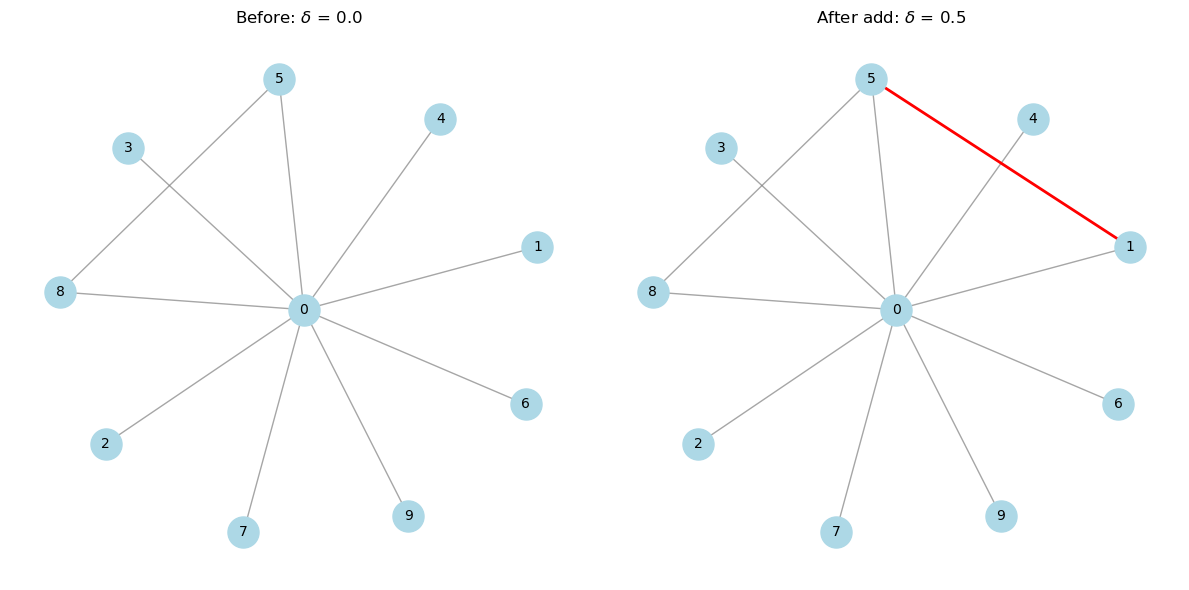

Quadruples: 7
Too many quadruples to visualize (7), showing only the first 3.


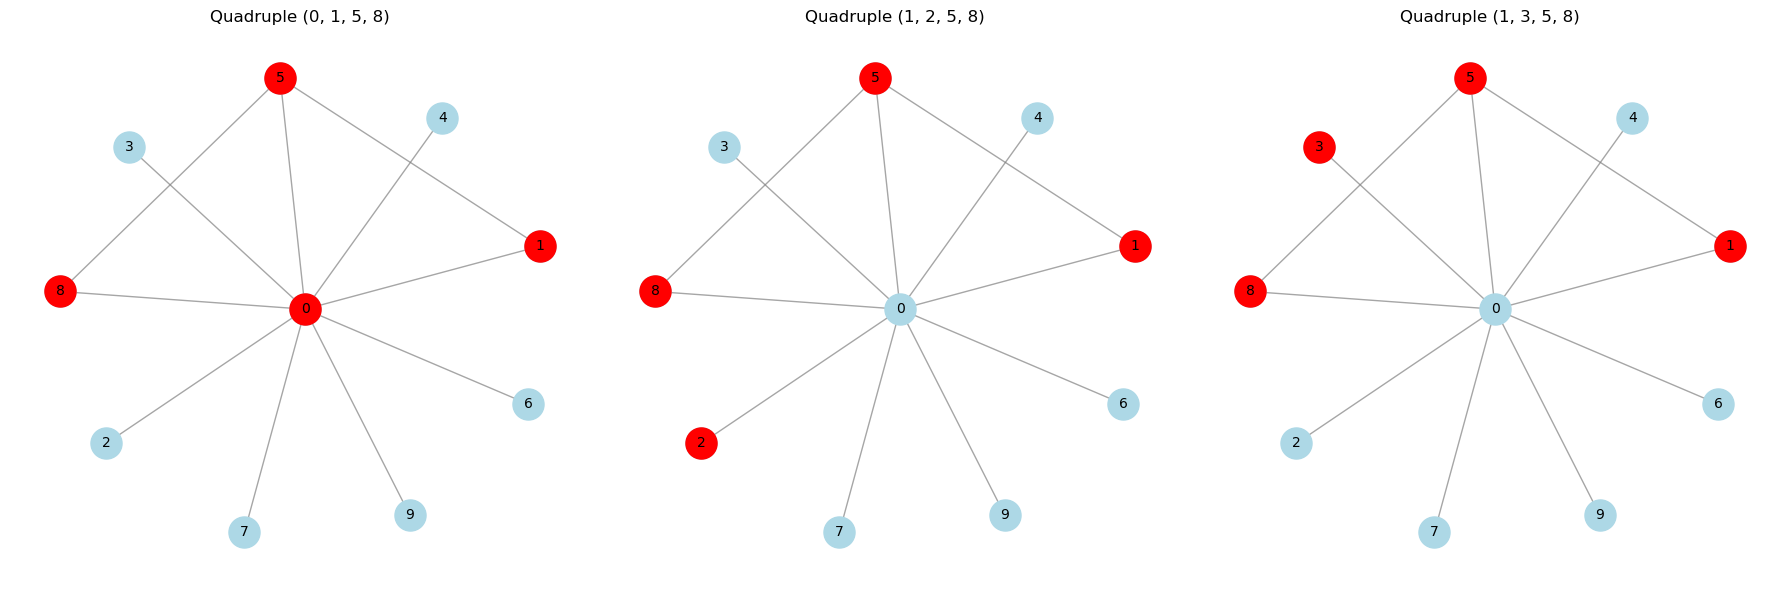


Step n. 1
We found 1 optimal edges.
Action: remove edge (0, 5) (Value: 1.0000)


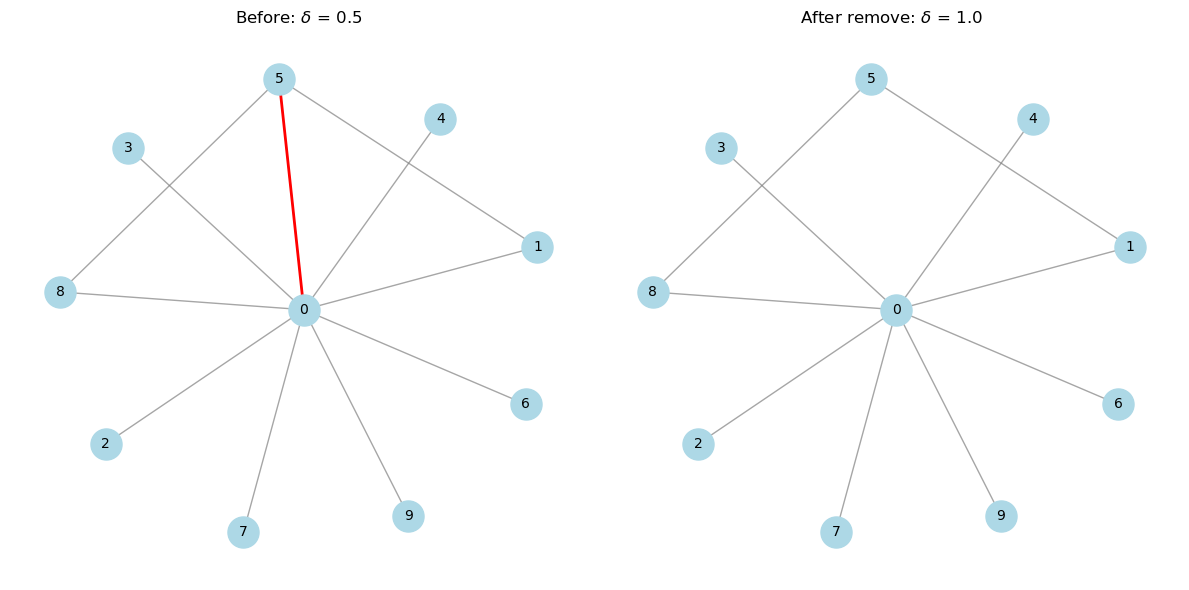

Quadruples: 7
Too many quadruples to visualize (7), showing only the first 3.


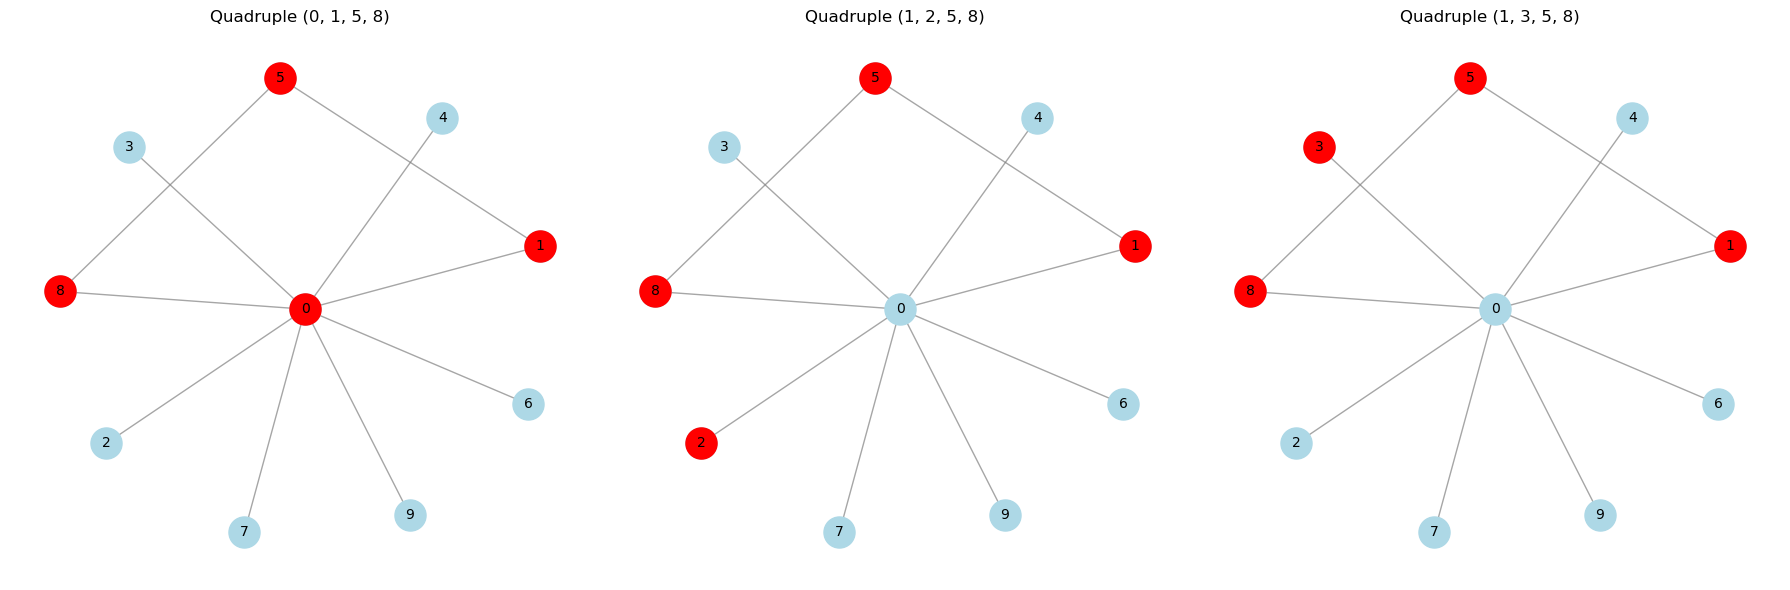


Step n. 2
Removed random edge: (0, 3)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 6
Removed random edge: (0, 9)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 5
Added random edge: (6, 9)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 6
Removed random edge: (5, 8)
Current Gromov after fallback: 0.0
Number of quadruples after fallback: 126
Added random edge: (4, 5)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 6
Added random edge: (1, 8)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 5
Added random edge: (4, 7)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 4
Added random edge: (3, 5)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 8
Added random edge: (2, 8)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 8
Added random edge: (3, 9)
Current Gromov after fallback: 1.0
Number of quadruples

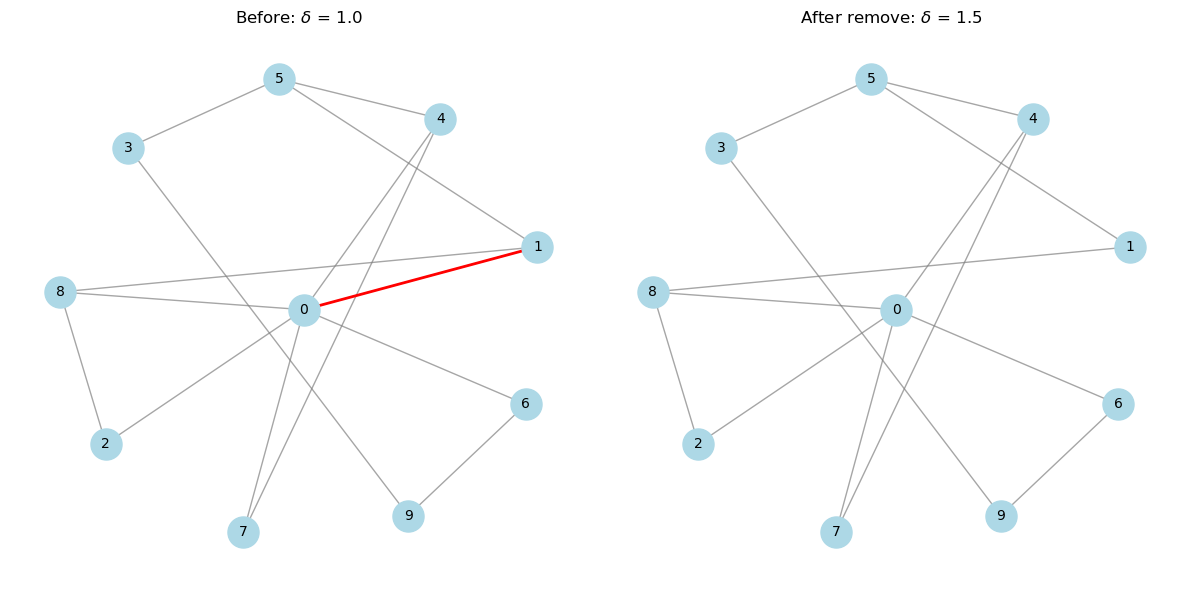

Quadruples: 1


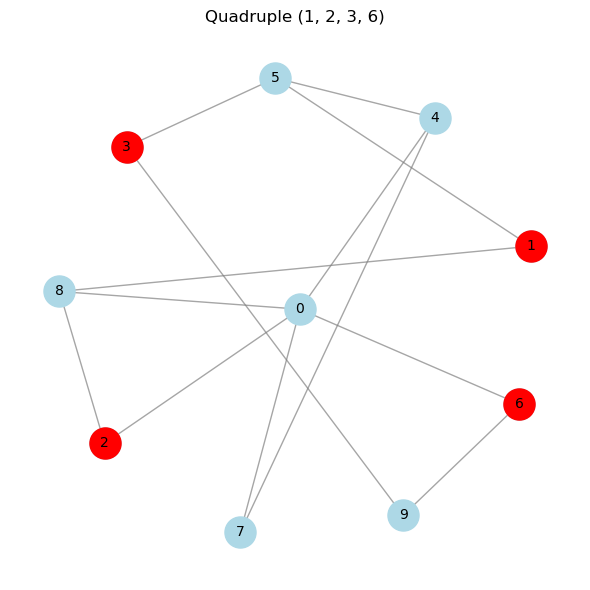


Step n. 3
We found 1 optimal edges.
Action: remove edge (0, 8) (Value: 2.0000)


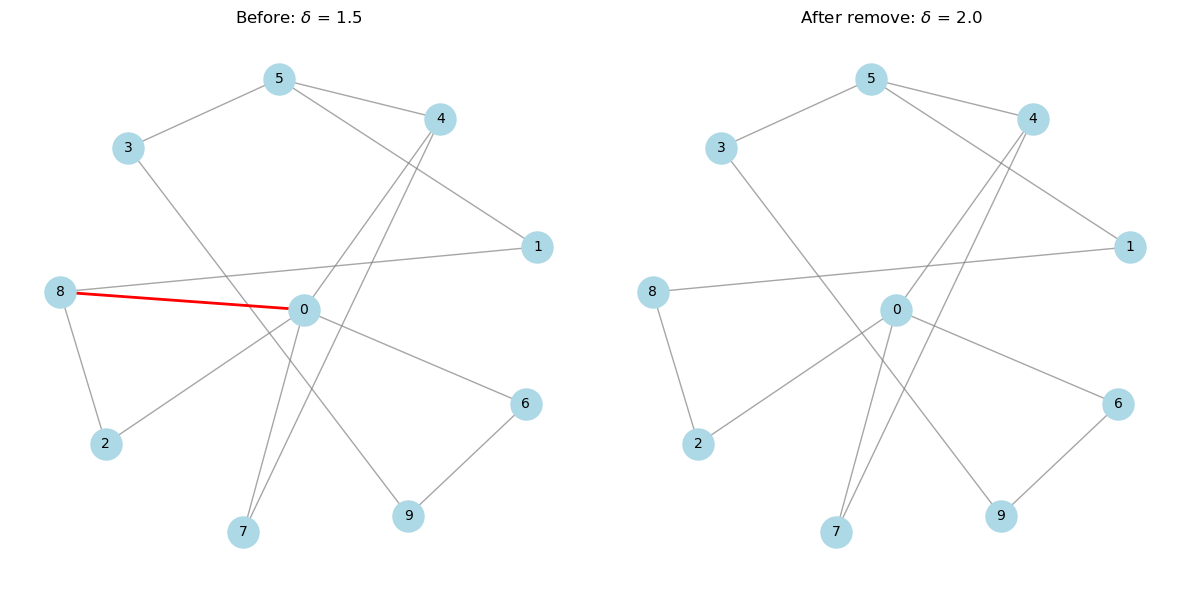

Quadruples: 1


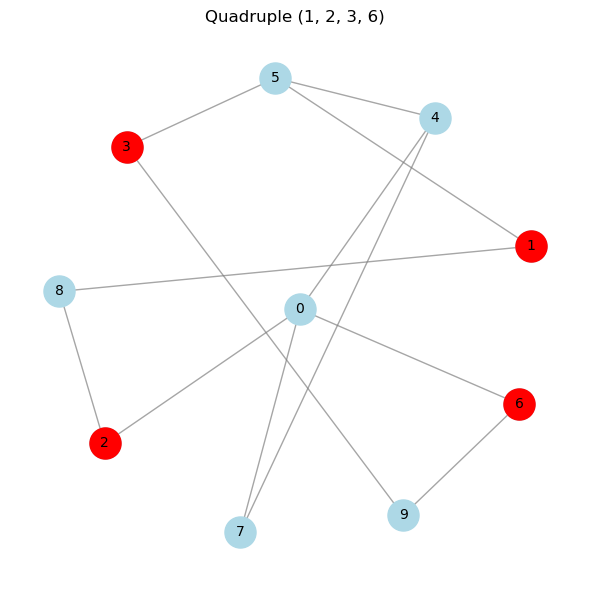


Step n. 4
Added random edge: (1, 2)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 27
Added random edge: (4, 6)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 13
Added random edge: (5, 8)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 13
Added random edge: (3, 4)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 12
Added random edge: (0, 1)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 10
Added random edge: (3, 8)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 21
Added random edge: (0, 5)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 20
Added random edge: (2, 6)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 10
Added random edge: (4, 8)
Current Gromov after fallback: 1.0
Number of quadruples after fallback: 9
Added random edge: (0, 8)
Current Gromov after fallback: 1.0
Number of quadruples

In [32]:
for step in range(n_steps):
    print(f"\n{'='*30}\nStep n. {step}\n{'='*30}")
    
    # 1. Trova le possibili modifiche
    found_edges = evolve_topology_strategy(G, pos=pos, target=target, strategy=strategy, p=p, max_steps=100)
    
    if not found_edges:
        actual_gromov = compute_gromov_on_graph(G)
        print('The final gromov is: ' + str(actual_gromov))
        print("No moves found. Stopping.")
        continue

    # 2. Ordina le modifiche (usando la tua logica sulla terza dimensione della tupla)
    # Assumendo found_edges sia [(azione, (u, v), valore), ...]
    found_edges.sort(key=lambda x: x[2], reverse=(target == 'increase'))
    
    action, edge, delta_val = found_edges[0]
    print(f"Action: {action} edge {edge} (Value: {delta_val:.4f})")

    # 3. Applica la modifica
    G_old = G.copy()
    if action == 'add':
        G.add_edge(*edge)
    else:
        G.remove_edge(*edge)

    # 4. Calcolo nuovo stato
    new_gromov, _, new_quadruples = compute_gromov_on_graph(G, return_history=True)
    
    # 5. Visualizzazione compatta
    # Decidiamo cosa evidenziare in base all'azione
    h_edges = [[edge], None] if action == 'remove' else [None, [edge]]
    
    draw_graphs(
        [G_old, G], 
        [pos, pos], 
        titles=[
            f"Before: $\\delta$ = {actual_gromov}", 
            f"After {action}: $\\delta$ = {new_gromov}"
        ],
        highlight_edges=h_edges
    )
    print(f"Quadruples: {len(new_quadruples)}")
    draw_quadruples(G, pos, new_quadruples, max_to_draw=3)
    # 6. Aggiorna stato
    actual_gromov = new_gromov

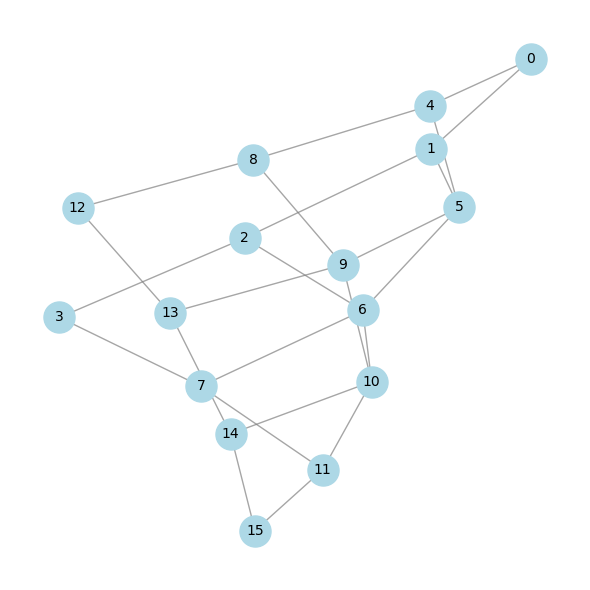

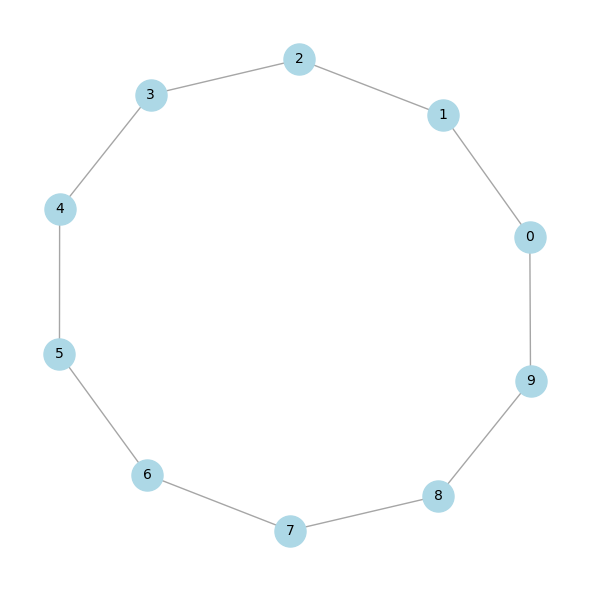

Actual gromov hyperbolicity: 2.0
Number of quadruples that satisfy the delta_max is: 15


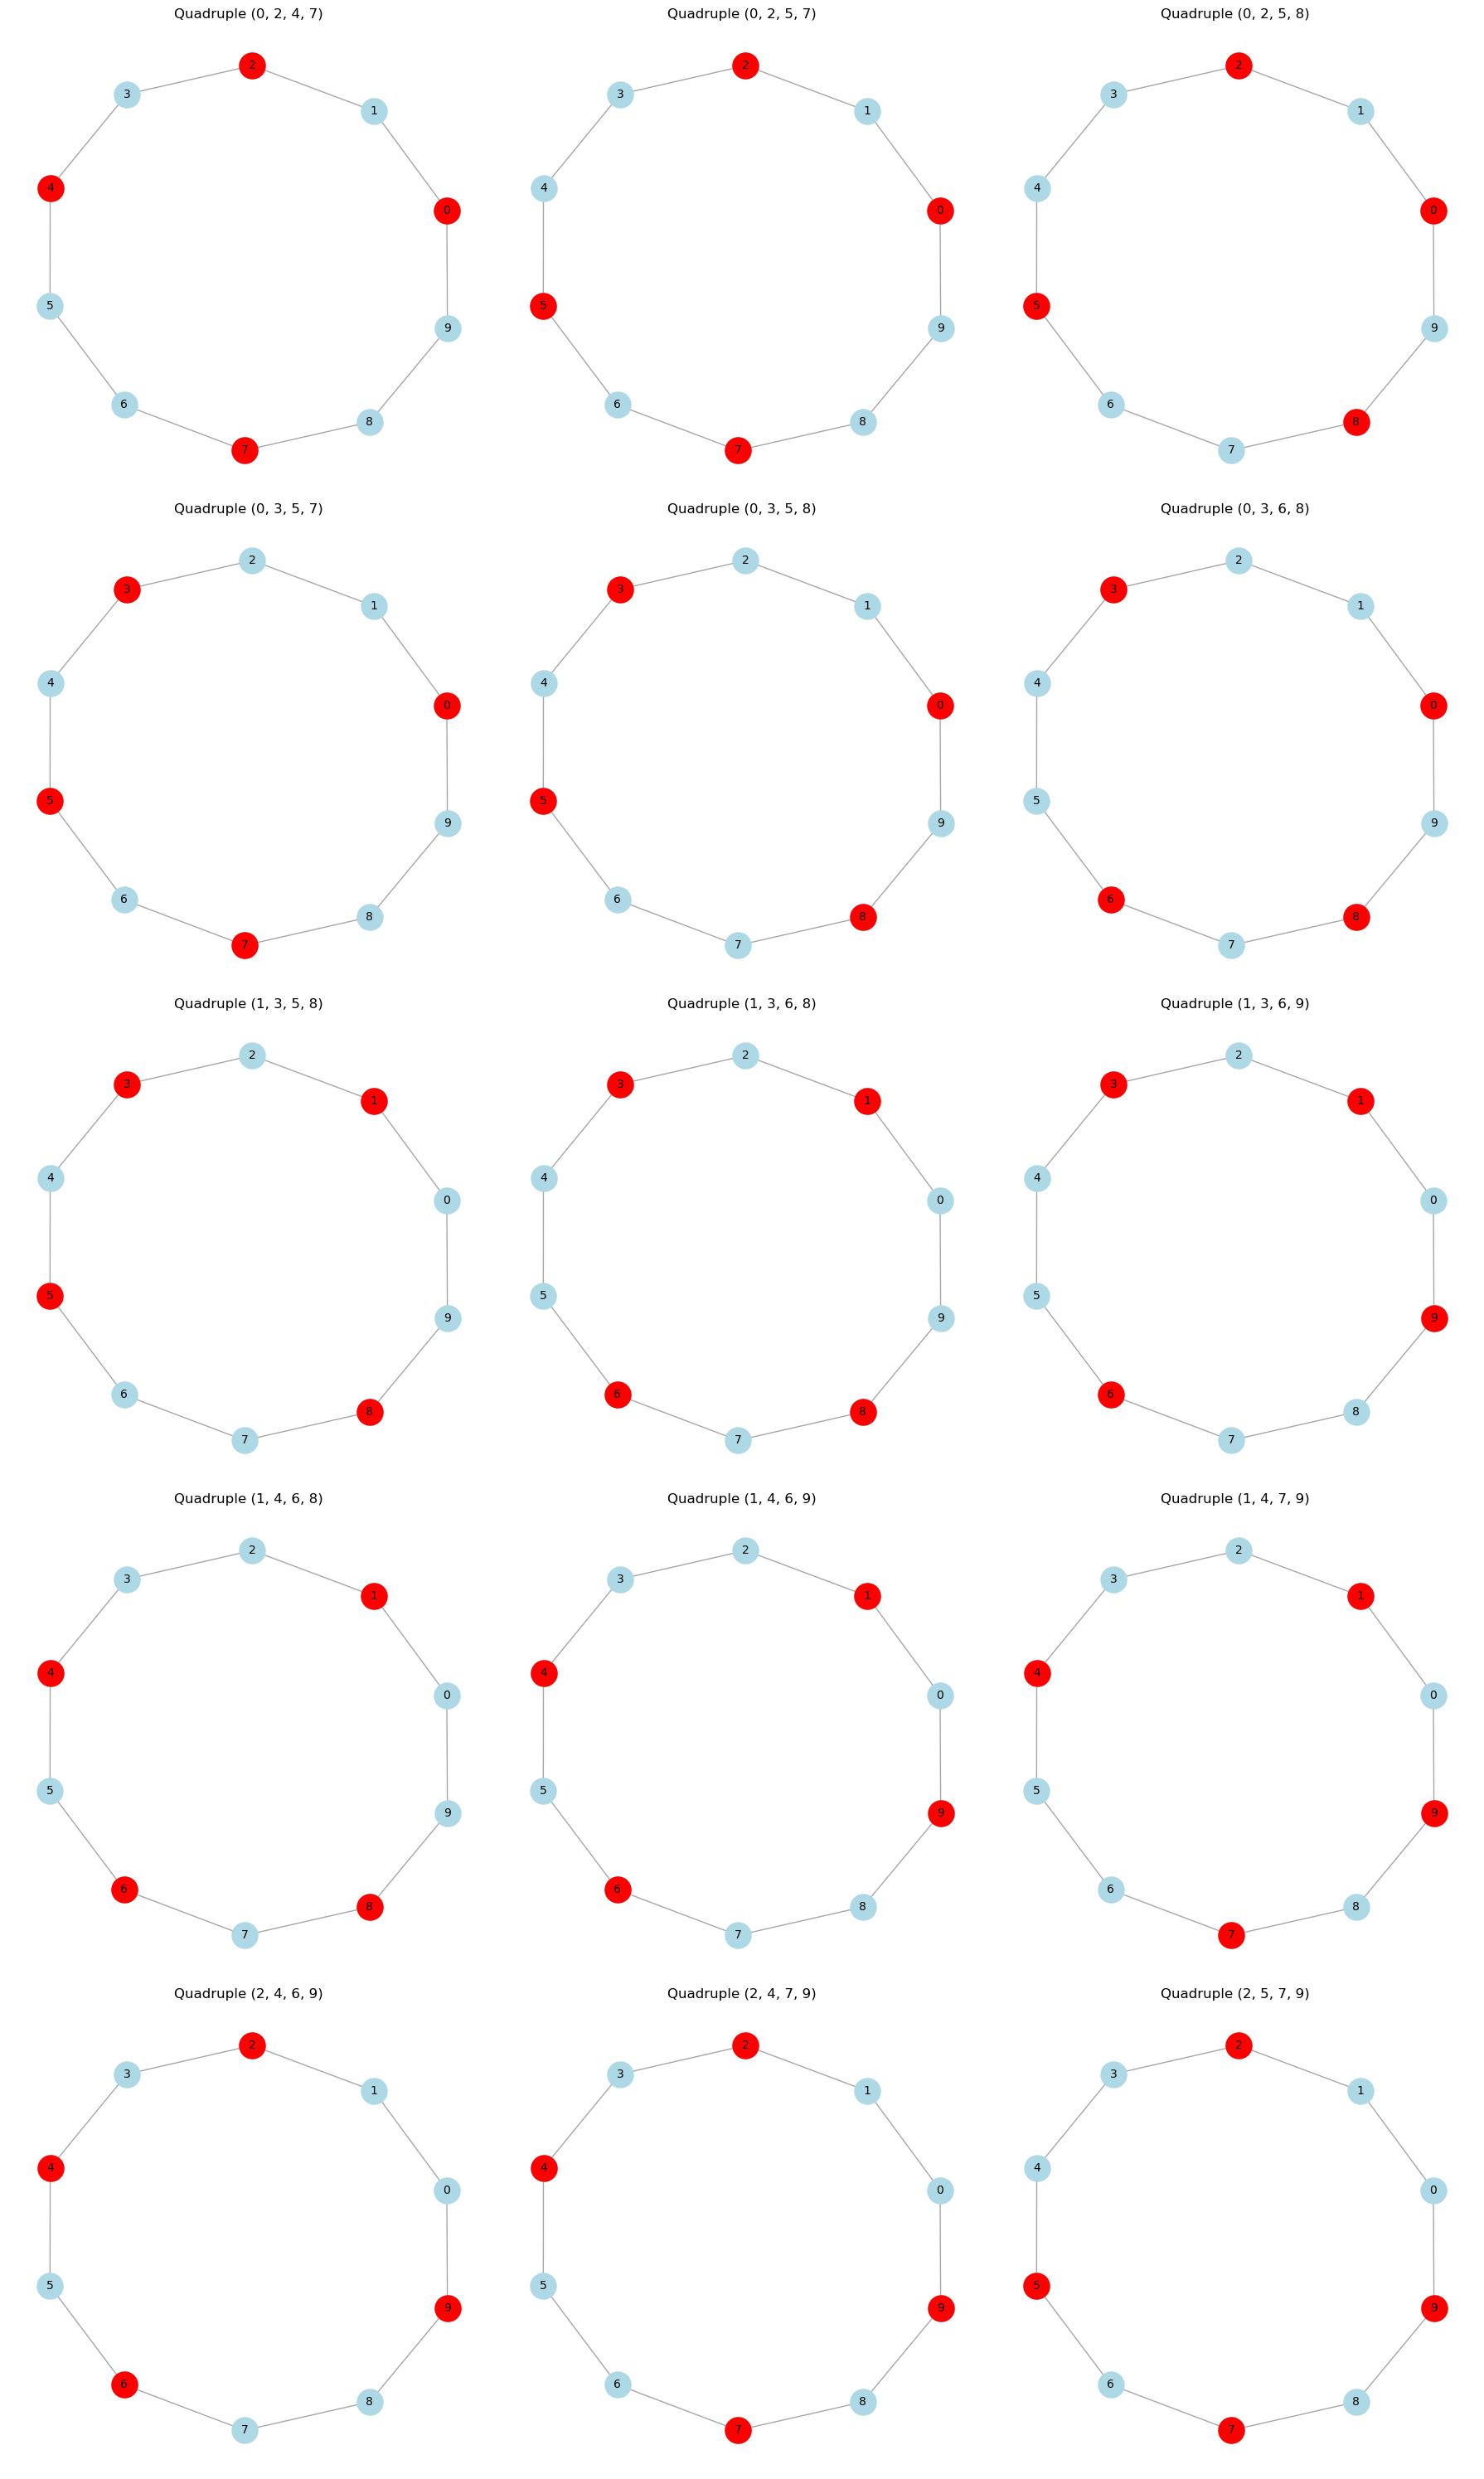

Step n. 0
------------------

We found 25 optimal edges.
We are going to add the first edge found: (0, 4)
actual gromov := 1.5


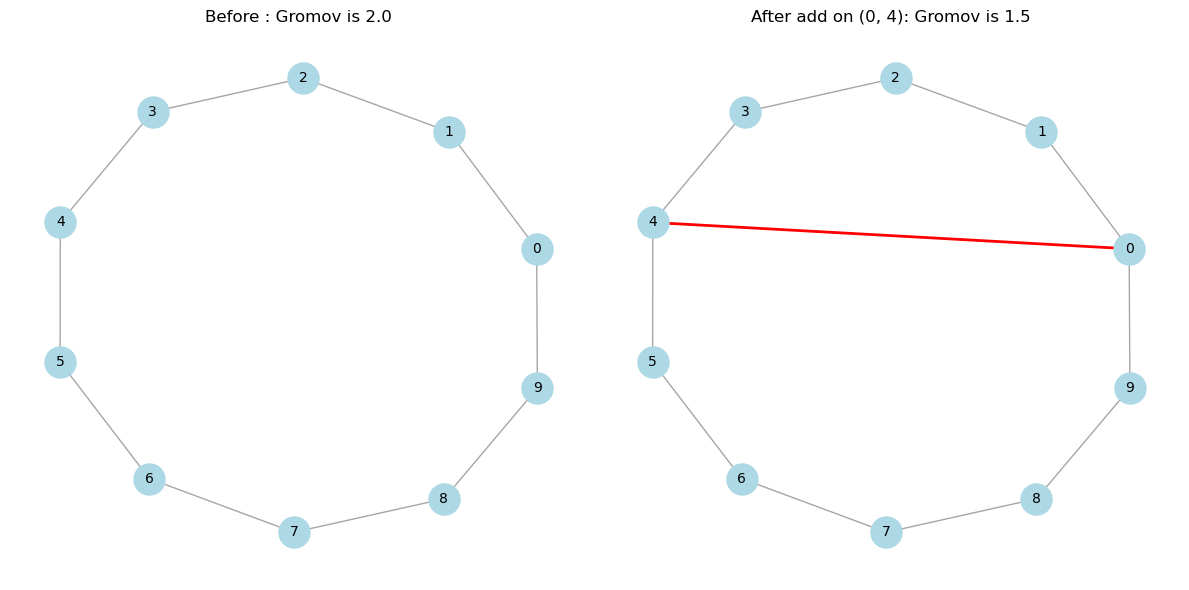

Step n. 1
------------------

We found 32 optimal edges.
We are going to add the first edge found: (0, 2)
actual gromov := 1.0


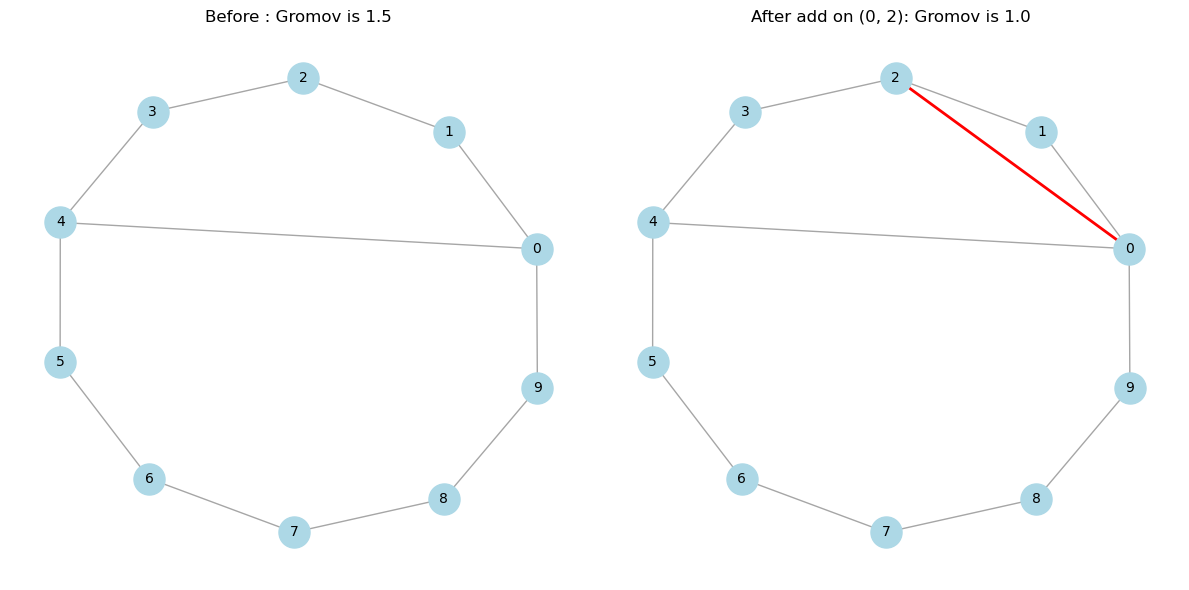

Step n. 2
------------------

Added random edge: (0, 3)
We found 6 optimal edges.
We are going to remove the first edge found: (0, 9)
actual gromov := 0.5


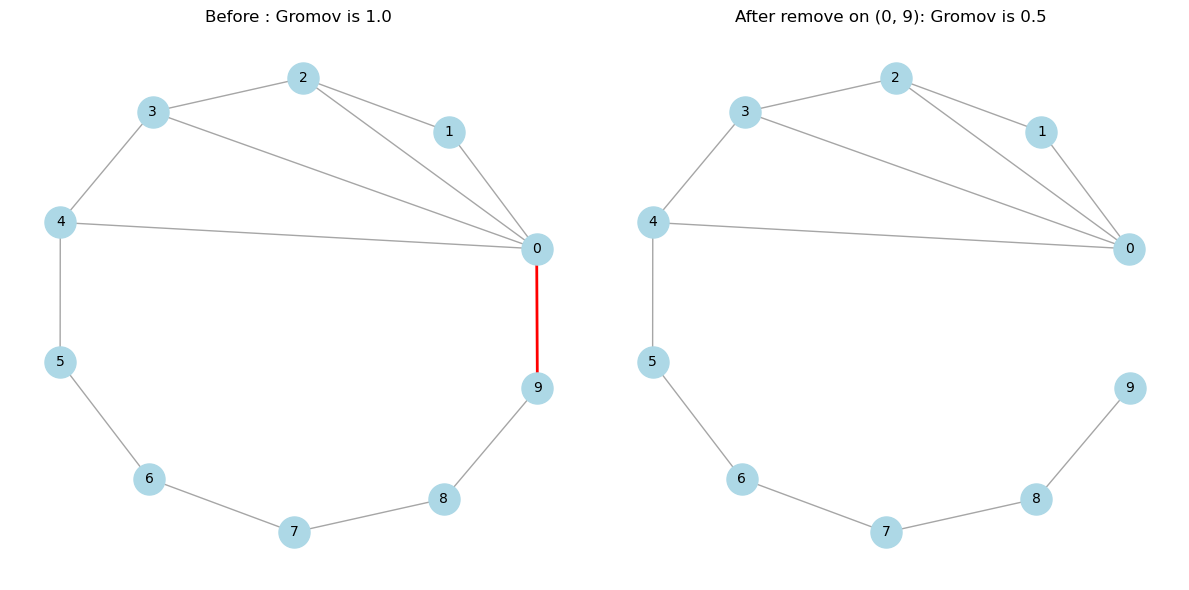

Step n. 3
------------------

We found 1 optimal edges.
We are going to remove the first edge found: (2, 3)
actual gromov := 0.0


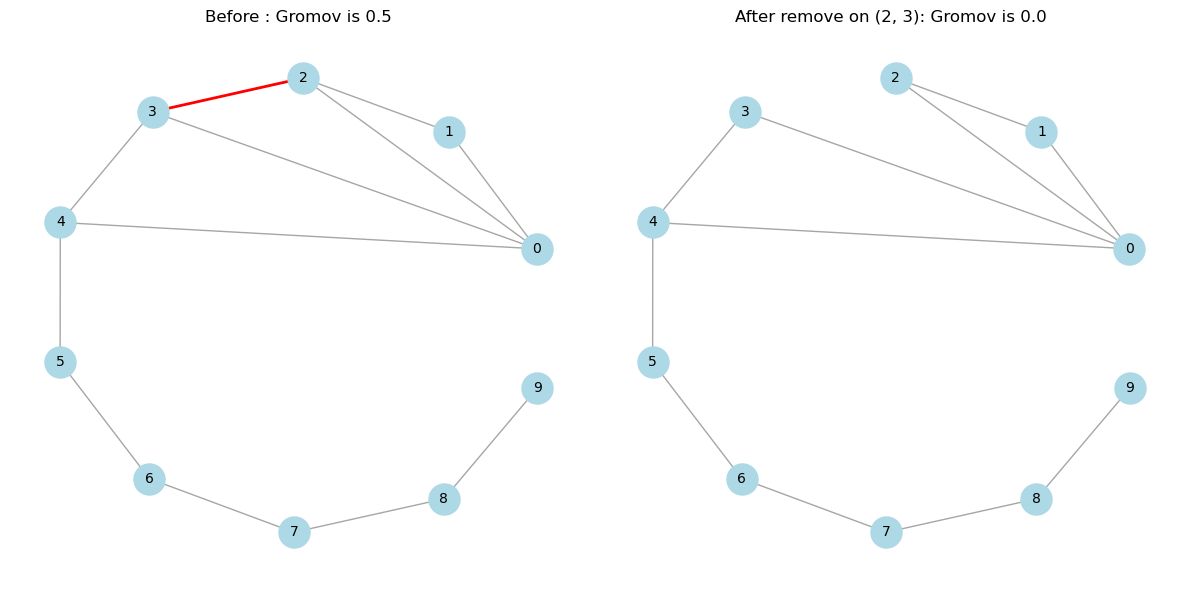

Step n. 4
------------------

Added random edge: (3, 7)
Added random edge: (6, 8)
Added random edge: (3, 6)
Added random edge: (0, 9)
Added random edge: (1, 4)
Added random edge: (7, 9)
Added random edge: (5, 8)
Added random edge: (5, 7)
Added random edge: (0, 7)
Added random edge: (4, 6)
Added random edge: (5, 9)
Added random edge: (1, 5)
Added random edge: (2, 3)
Added random edge: (1, 8)
Added random edge: (4, 8)
Added random edge: (0, 8)
Added random edge: (3, 8)
Added random edge: (3, 9)
Added random edge: (2, 5)
Added random edge: (1, 3)
Added random edge: (6, 9)
Added random edge: (4, 7)
Added random edge: (1, 6)
Added random edge: (1, 9)
Added random edge: (3, 5)
Added random edge: (2, 7)
Added random edge: (2, 8)
Added random edge: (4, 9)
Added random edge: (0, 6)
Added random edge: (2, 6)
Added random edge: (1, 7)
Added random edge: (2, 4)
Added random edge: (2, 9)
Added random edge: (0, 5)
No more edges to add.
We found 0 optimal edges.
We found nothing of nothing, just brea

In [17]:
G = nx.cartesian_product(nx.path_graph(4), nx.path_graph(4))
G = nx.convert_node_labels_to_integers(G)
pos = draw_layout(G)
draw_graphs(G, pos)


n = 10
G = create_cycle_graph(n=n)
pos = draw_layout(G, pos=None)
draw_graphs(G, pos)
target = 'decrease'  # 'increase' or 'decrease'
strategy = 'add' # 'add', 'remove', 'mixed'

max_delta, _, quadruples = compute_gromov_on_graph(G, return_history=True)
old_gromov = max_delta
print(f"Actual gromov hyperbolicity: {max_delta}")

print(f"Number of quadruples that satisfy the delta_max is: {len(quadruples)}")
draw_quadruples(G, pos, quadruples)

for num_step in range(0,5):
    print(f'Step n. {num_step}')
    print('------------------\n')
    
    found_edges = evolve_topology_strategy(G,target=target, strategy=strategy)
    if not found_edges:
        print("We found nothing of nothing, just break the cycle")
        break
    #found_edges = sorted(found_edges, key=lambda x: x[2], reverse=False if target=='decrease' else True)
    action = found_edges[0][0]
    print(f'We are going to {found_edges[0][0]} the first edge found: {found_edges[0][1]}')
    G_old = G.copy()   
    if action == 'add':
        G.add_edge(*found_edges[0][1])
    elif action == 'remove':
        G.remove_edge(*found_edges[0][1])
    actual_gromov, _, quadruples = compute_gromov_on_graph(G,return_history=True)
    print(f'actual gromov := {actual_gromov}')
    if action == 'remove':    
        draw_graphs([G_old,G], [pos,pos], titles=[f"Before : Gromov is {old_gromov}", f"After {action} on {found_edges[0][1]}: Gromov is {actual_gromov}"], highlight_edges=[[found_edges[0][1]], None])
    else:
        draw_graphs([G_old,G], [pos,pos], titles=[f"Before : Gromov is {old_gromov}", f"After {action} on {found_edges[0][1]}: Gromov is {actual_gromov}"], highlight_edges=[None, [found_edges[0][1]]])
    #draw_quadruples(G, pos, quadruples)
    old_gromov = actual_gromov
 